In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
plt.style.use('default')

In [2]:
DATASET_PATH = "./dataset/" 
ORIG_DIR = os.path.join(DATASET_PATH, 'originalData')
MASK_DIR = os.path.join(DATASET_PATH, 'annotatedData')

In [3]:
T_PATCH = 16   # Temporal depth (frames)
H_PATCH = 32   # Spatial height
W_PATCH = 32   # Spatial width
STRIDE = 16    # Overlap for patch extraction
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 1e-3

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
def natural_key(string_):
    return [int(s) if s.isdigit() else s.lower() for s in re.split('([0-9]+)', string_)]

In [6]:
orig_files = sorted([f for f in os.listdir(ORIG_DIR) if not f.startswith('.')], key=natural_key)

thermal_sequence_list = []
mask_sequence_list = []

for filename in orig_files:
    orig_path = os.path.join(ORIG_DIR, filename)
    mask_path = os.path.join(MASK_DIR, filename)
    
    orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)    
    thermal_sequence_list.append(orig_img)
    if mask_img is not None:
        _, binary_mask = cv2.threshold(mask_img, 1, 255, cv2.THRESH_BINARY)
        mask_sequence_list.append(binary_mask / 255.0) 

In [7]:
thermal_volume = np.stack(thermal_sequence_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_sequence_list, axis=0).astype(np.float32)

print(f"Volume loaded. Shape: {thermal_volume.shape}")

Volume loaded. Shape: (1034, 234, 234)


In [8]:
vol_min = thermal_volume.min()
vol_max = thermal_volume.max()
thermal_volume_norm = (thermal_volume - vol_min) / (vol_max - vol_min)

In [9]:
class SpatialTemporalAutoencoder(nn.Module):
    def __init__(self, in_channels=1):
        super(SpatialTemporalAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv3d(in_channels, 16, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose3d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose3d(16, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [10]:
class HealthyThermalPatches(Dataset):
    def __init__(self, thermal_data, mask_data, t_patch, h_patch, w_patch, stride):
        self.thermal_data = thermal_data
        self.t_patch = t_patch
        self.h_patch = h_patch
        self.w_patch = w_patch
        self.valid_coords = []
        
        T, H, W = thermal_data.shape
        
        if np.mean(mask_data) > 0.5:
            print("Notice: Masks appear inverted. Flipping background to 0...")
            mask_data = 1.0 - mask_data
            
        for y in range(0, H - h_patch + 1, stride):
            for x in range(0, W - w_patch + 1, stride):
                for t in range(0, T - t_patch + 1, t_patch):
                    mask_patch = mask_data[t:t+t_patch, y:y+h_patch, x:x+w_patch]
                    if np.sum(mask_patch) <= 5: 
                        self.valid_coords.append((t, y, x))
                        
        print(f"Found {len(self.valid_coords)} healthy patches for training.")

    def __len__(self):
        return len(self.valid_coords)

    def __getitem__(self, idx):
        t, y, x = self.valid_coords[idx]
        patch = self.thermal_data[t:t+self.t_patch, y:y+self.h_patch, x:x+self.w_patch]
        patch = np.expand_dims(patch, axis=0) 
        return torch.tensor(patch, dtype=torch.float32)

In [11]:
model = SpatialTemporalAutoencoder(in_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.L1Loss() # L1 Loss preserves sharp thermal boundaries

train_dataset = HealthyThermalPatches(
    thermal_volume_norm, mask_volume, 
    t_patch=T_PATCH, h_patch=H_PATCH, w_patch=W_PATCH, stride=STRIDE
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Found 10050 healthy patches for training.


In [12]:
epoch_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for batch_idx, patches in enumerate(train_loader):
        patches = patches.to(device)
        
        optimizer.zero_grad()
        reconstructed = model(patches)
        loss = criterion(reconstructed, patches)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss) # Store the loss for plotting
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Average L1 Loss: {avg_loss:.6f}")

Epoch [1/15] - Average L1 Loss: 0.034215
Epoch [2/15] - Average L1 Loss: 0.018257
Epoch [3/15] - Average L1 Loss: 0.017382
Epoch [4/15] - Average L1 Loss: 0.016677
Epoch [5/15] - Average L1 Loss: 0.016403
Epoch [6/15] - Average L1 Loss: 0.016594
Epoch [7/15] - Average L1 Loss: 0.016127
Epoch [8/15] - Average L1 Loss: 0.016006
Epoch [9/15] - Average L1 Loss: 0.016079
Epoch [10/15] - Average L1 Loss: 0.016068
Epoch [11/15] - Average L1 Loss: 0.015892
Epoch [12/15] - Average L1 Loss: 0.015719
Epoch [13/15] - Average L1 Loss: 0.015793
Epoch [14/15] - Average L1 Loss: 0.015535
Epoch [15/15] - Average L1 Loss: 0.015188


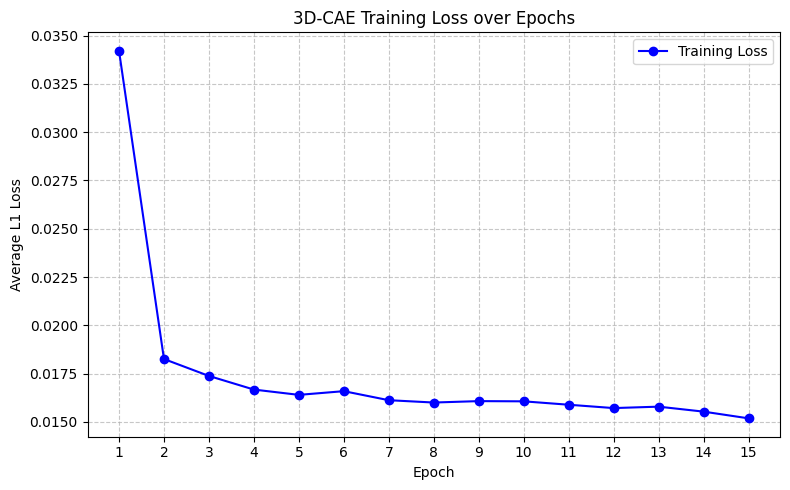

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('3D-CAE Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average L1 Loss')
plt.xticks(range(1, EPOCHS + 1)) # Ensure x-axis shows whole numbers for epochs
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
model.eval()

SpatialTemporalAutoencoder(
  (encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose3d(64, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose3d(32, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): ConvTranspose3d(16, 1, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (5): Sigmoid()
  )
)

In [15]:
defective_patch_tensor = None
T, H, W = thermal_volume_norm.shape

for y in range(0, H - H_PATCH + 1, STRIDE):
    for x in range(0, W - W_PATCH + 1, STRIDE):
        for t in range(0, T - T_PATCH + 1, T_PATCH):
            mask_patch = mask_volume[t:t+T_PATCH, y:y+H_PATCH, x:x+W_PATCH]
            if np.sum(mask_patch) > 50:  # Find a patch with a significant defect
                patch = thermal_volume_norm[t:t+T_PATCH, y:y+H_PATCH, x:x+W_PATCH]
                # Shape: (Batch=1, Channels=1, T, H, W)
                defective_patch_tensor = torch.tensor(np.expand_dims(np.expand_dims(patch, axis=0), axis=0), dtype=torch.float32)
                break
        if defective_patch_tensor is not None: break
    if defective_patch_tensor is not None: break

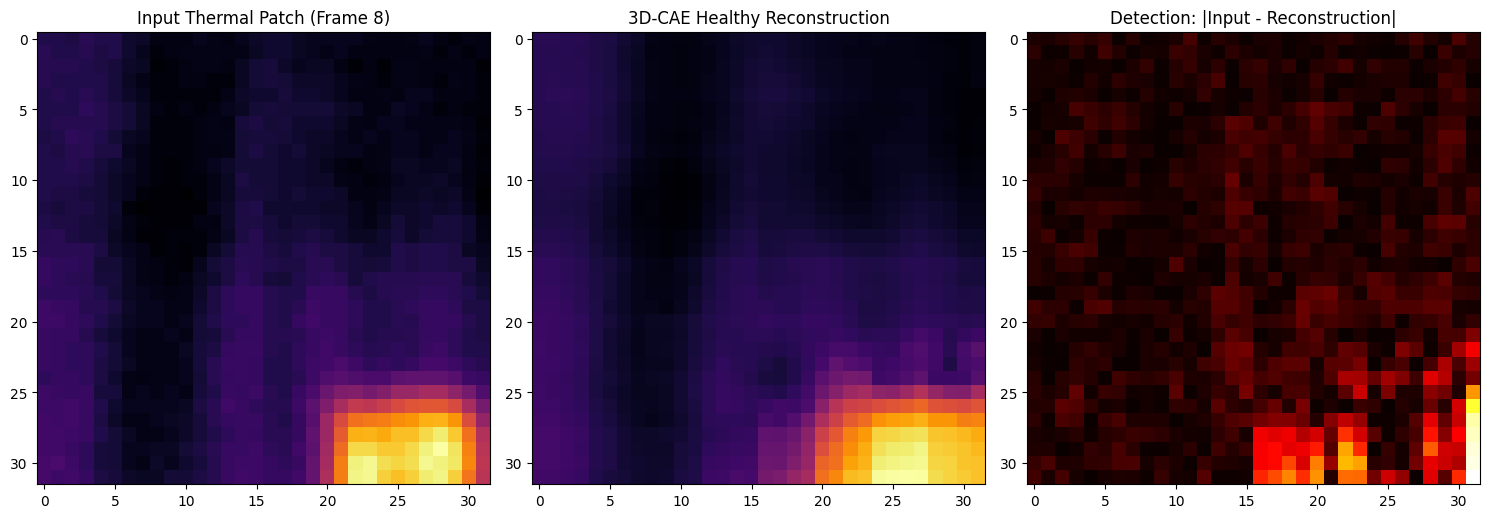

In [16]:
if defective_patch_tensor is not None:
    defective_patch_tensor = defective_patch_tensor.to(device)
    
    with torch.no_grad():
        reconstructed_tensor = model(defective_patch_tensor)
        
    input_np = defective_patch_tensor.cpu().numpy()[0, 0]
    recon_np = reconstructed_tensor.cpu().numpy()[0, 0]
    
    middle_frame = T_PATCH // 2
    input_img = input_np[middle_frame, :, :]
    recon_img = recon_np[middle_frame, :, :]
    
    error_map = np.abs(input_img - recon_img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))    
    axes[0].imshow(input_img, cmap='inferno')
    axes[0].set_title(f"Input Thermal Patch (Frame {middle_frame})")
    axes[1].imshow(recon_img, cmap='inferno')
    axes[1].set_title("3D-CAE Healthy Reconstruction")
    axes[2].imshow(error_map, cmap='hot')
    axes[2].set_title("Detection: |Input - Reconstruction|")
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a defective patch in the mask volume to visualize.")

In [17]:
model.eval()

SpatialTemporalAutoencoder(
  (encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose3d(64, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose3d(32, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): ConvTranspose3d(16, 1, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1))
    (5): Sigmoid()
  )
)

In [18]:
T_full, H_full, W_full = thermal_volume_norm.shape
best_t = 0
max_defect_pixels = 0

for t in range(0, T_full - T_PATCH + 1):
    defect_pixels = np.sum(mask_volume[t:t+T_PATCH, :, :])
    if defect_pixels > max_defect_pixels:
        max_defect_pixels = defect_pixels
        best_t = t

print(f"Selected time window starting at frame {best_t} for full reconstruction.")

Selected time window starting at frame 0 for full reconstruction.


In [19]:
full_reconstruction = np.zeros((T_PATCH, H_full, W_full), dtype=np.float32)
overlap_count = np.zeros((T_PATCH, H_full, W_full), dtype=np.float32)

INFERENCE_STRIDE = 8 

with torch.no_grad():
    for y in range(0, H_full - H_PATCH + 1, INFERENCE_STRIDE):
        for x in range(0, W_full - W_PATCH + 1, INFERENCE_STRIDE):
            patch = thermal_volume_norm[best_t:best_t+T_PATCH, y:y+H_PATCH, x:x+W_PATCH]
            patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            reconstructed_patch = model(patch_tensor).cpu().numpy()[0, 0]
            full_reconstruction[:, y:y+H_PATCH, x:x+W_PATCH] += reconstructed_patch
            overlap_count[:, y:y+H_PATCH, x:x+W_PATCH] += 1

overlap_count[overlap_count == 0] = 1
full_reconstruction /= overlap_count

mid_idx = T_PATCH // 2
original_full_frame = thermal_volume_norm[best_t + mid_idx, :, :]
reconstructed_full_frame = full_reconstruction[mid_idx, :, :]
full_error_map = np.abs(original_full_frame - reconstructed_full_frame)

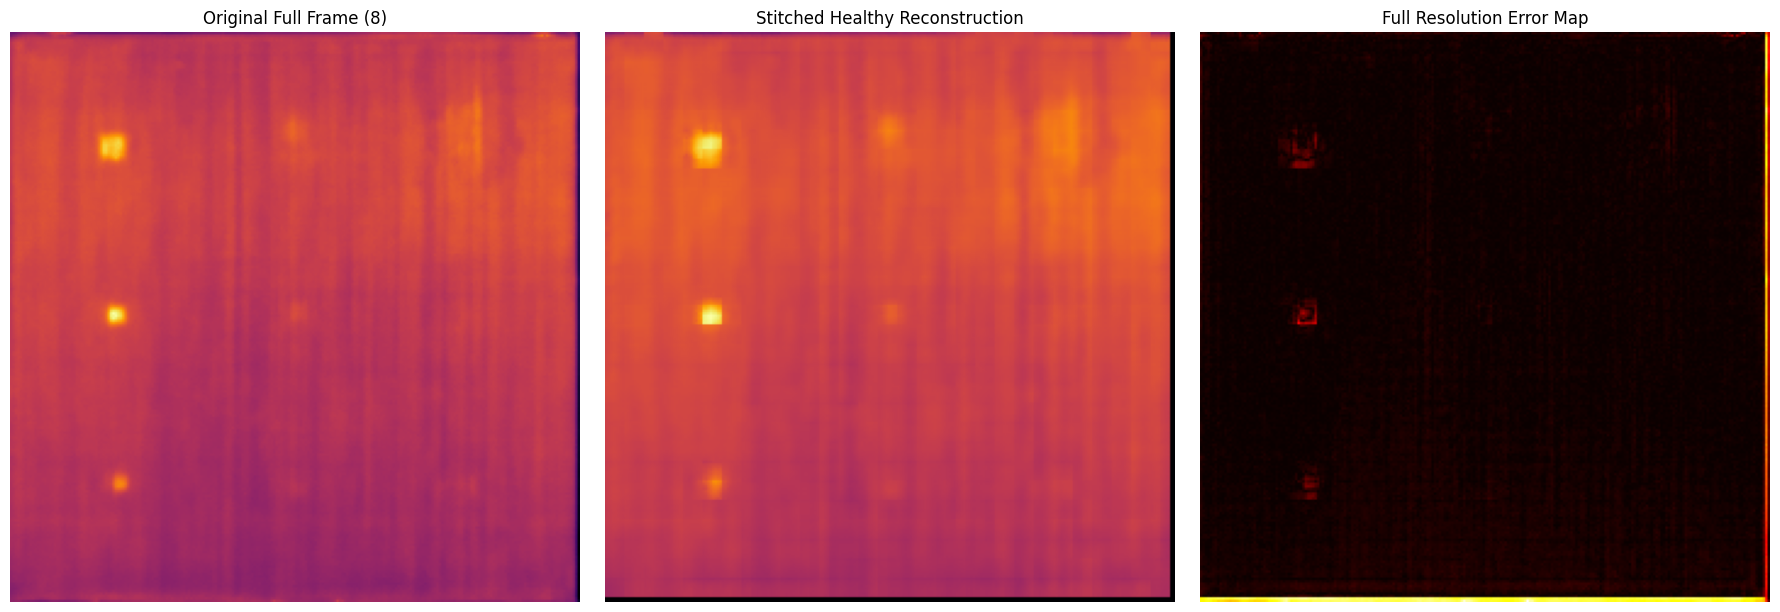

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(original_full_frame, cmap='inferno')
axes[0].set_title(f"Original Full Frame ({best_t + mid_idx})")
axes[0].axis('off')
axes[1].imshow(reconstructed_full_frame, cmap='inferno')
axes[1].set_title("Stitched Healthy Reconstruction")
axes[1].axis('off')
axes[2].imshow(full_error_map, cmap='hot')
axes[2].set_title("Full Resolution Error Map")
axes[2].axis('off')
plt.tight_layout()
plt.show()